# Pattern Recognition and Machine Learning (EE602L)
## Lab 1: Data Exploration and Preparation

**Roll No:** EC24BT033

**Dataset:** `insurance.csv`, medical insurance charges of 1,338 individuals.

<style>pre, code { white-space: pre-wrap !important; word-break: break-word; }</style>

In [ ]:
# Imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

## Q1. Load the dataset: shape, columns, dtypes, summary statistics

In [2]:
print("Shape (rows, cols):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows, cols): (1338, 7)

Column names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [3]:
# First few rows to see what the data looks like
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Summary statistics of the numeric columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Q1 Answers

- **Feature vector x:** `age`, `sex`, `bmi`, `children`, `smoker`, `region`. These are the attributes we use to make a prediction.
- **Label y:** `charges`, the quantity we want to predict.
- **N = 1338** (number of samples / rows), **d = 6** (number of raw feature columns, counted *before* any encoding; one-hot encoding `region` etc. would inflate this later).
- **Problem type: regression.** The target `charges` is a continuous real-valued quantity (it can take any positive value, including decimals). There is no finite set of classes to assign (like yes/no or 0/1), so this is not classification.
- **Connection to D = {(xᵢ, yᵢ)}:** This dataset is exactly D = {(xᵢ, yᵢ)}ᵢ₌₁,…,₁₃₃₈ where each xᵢ ∈ ℝᵈ (d = 6) is one person's attributes (age, sex, bmi, children, smoker, region) and yᵢ ∈ ℝ is that person's medical charges.

## Q2. Group-wise averages, correlations and plots

In [5]:
# Average charges grouped by each categorical factor
for col in ["smoker", "sex", "region"]:
    means = df.groupby(col)["charges"].mean().round(2)
    spread = means.max() - means.min()
    print(f"--- Mean charges by {col} ---")
    print(means.to_string())
    print(f"(max-min gap: {spread:,.2f})\n")

--- Mean charges by smoker ---
smoker
no      8434.27
yes    32050.23
(max-min gap: 23,615.96)

--- Mean charges by sex ---
sex
female    12569.58
male      13956.75
(max-min gap: 1,387.17)

--- Mean charges by region ---
region
northeast    13406.38
northwest    12417.58
southeast    14735.41
southwest    12346.94
(max-min gap: 2,388.47)



In [6]:
# Correlation of the numeric features with charges
corr_with_charges = df[["age", "bmi", "children", "charges"]].corr()["charges"]
corr_with_charges = corr_with_charges.drop("charges")
print(corr_with_charges.round(3))

age         0.299
bmi         0.198
children    0.068
Name: charges, dtype: float64


**Which factor matters most?** `smoker` by a huge margin. Smokers pay roughly **4x** the mean charges of non-smokers (a gap of about \$23,600). The gap across `region` (about \$2,400) and `sex` (about \$1,400) is small by comparison, so smoking status is clearly the dominant factor.

**Correlations:** `age` (about 0.30) has the strongest linear relationship with charges: older people incur higher costs. `bmi` (about 0.20) is weaker, and `children` (about 0.07) is nearly uncorrelated. All are positive but individually weak-to-moderate, so no single numeric feature explains charges alone.

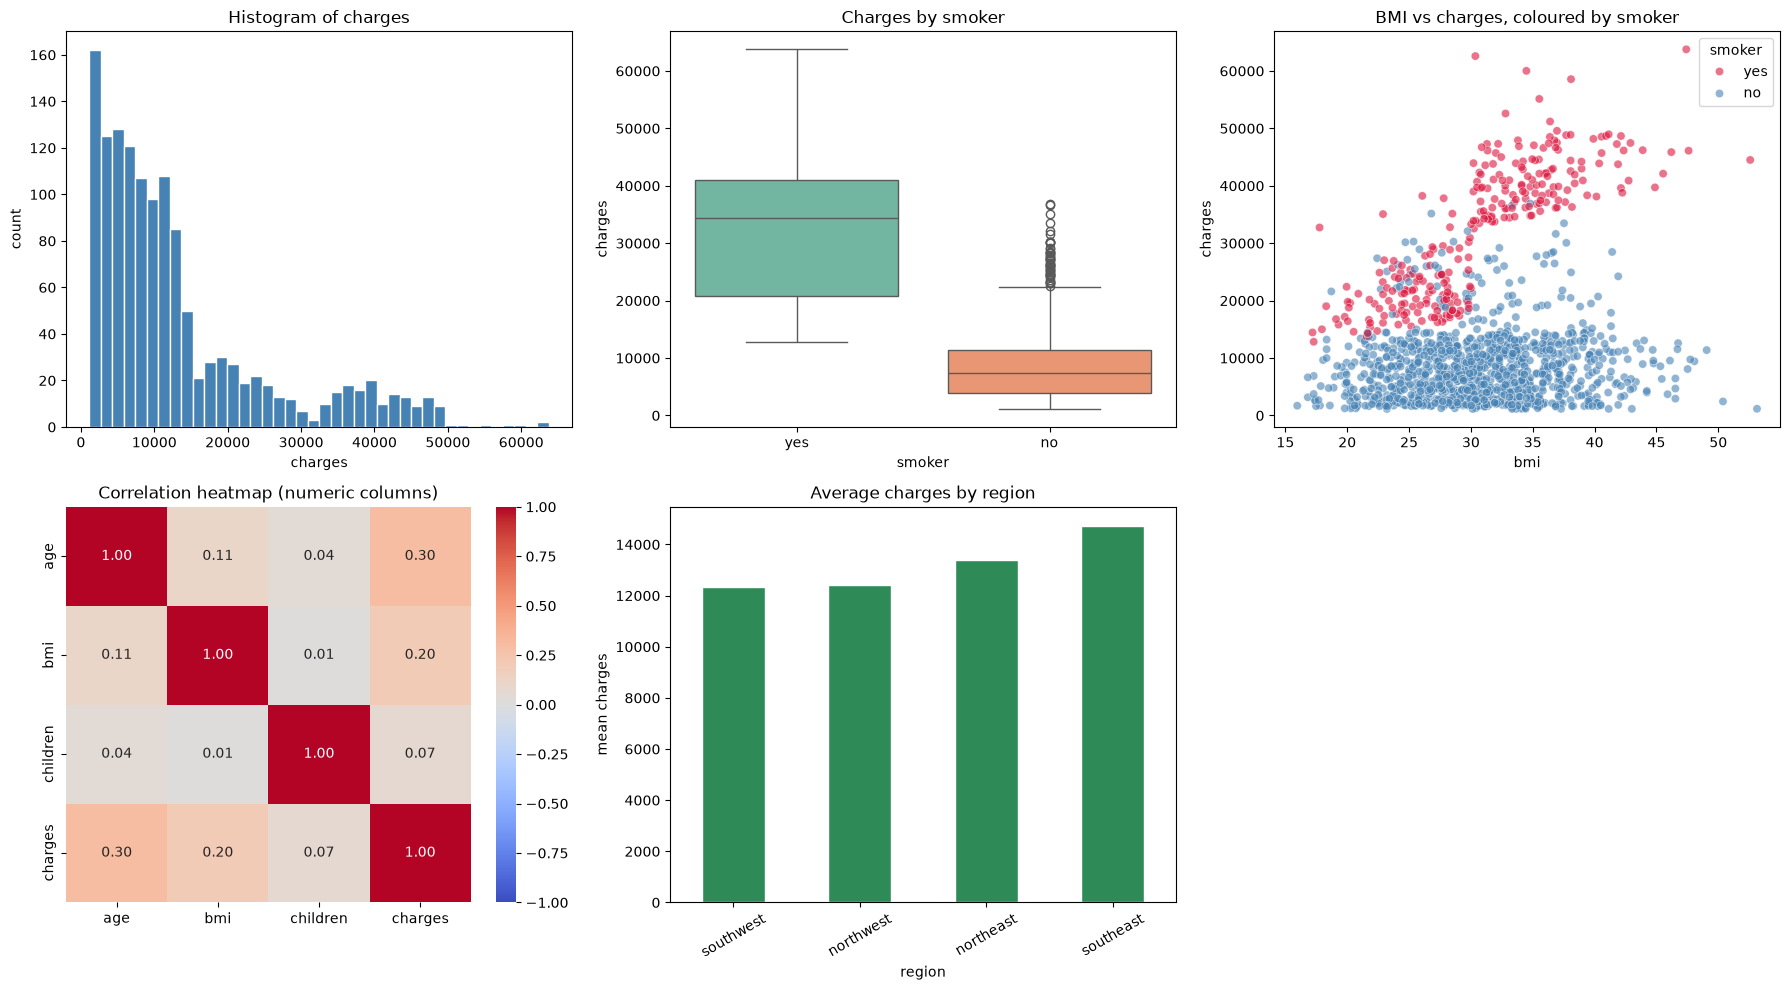

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogram of charges
axes[0, 0].hist(df["charges"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Histogram of charges")
axes[0, 0].set_xlabel("charges"); axes[0, 0].set_ylabel("count")

# 2. Boxplot of charges by smoker
sns.boxplot(data=df, x="smoker", y="charges", hue="smoker", ax=axes[0, 1], palette="Set2", legend=False)
axes[0, 1].set_title("Charges by smoker")

# 3. Scatter of bmi vs charges coloured by smoker
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[0, 2], alpha=0.6, palette={"yes": "crimson", "no": "steelblue"})
axes[0, 2].set_title("BMI vs charges, coloured by smoker")

# 4. Correlation heatmap of numeric columns
num_corr = df[["age", "bmi", "children", "charges"]].corr()
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title("Correlation heatmap (numeric columns)")

# 5. Bar chart of average charges by region
region_means = df.groupby("region")["charges"].mean().sort_values()
region_means.plot(kind="bar", ax=axes[1, 1], color="seagreen", edgecolor="white")
axes[1, 1].set_title("Average charges by region")
axes[1, 1].set_ylabel("mean charges")
axes[1, 1].tick_params(axis="x", rotation=30)

axes[1, 2].axis("off")  # unused panel
plt.tight_layout()
plt.show()

### Q2 Summary (3-4 sentences)

Charges are right-skewed: most people cost under \$15k, with a long tail of expensive cases. The boxplot and group means show smoking is by far the most important factor, since smoker median charges sit far above the entire non-smoker distribution. The scatter plot reveals an **interaction**: for non-smokers charges stay low at any BMI, but for smokers charges jump sharply once BMI is high (obese smokers form a separate high-cost cluster), so BMI matters mainly *in combination with* smoking. Among numeric features, age has the strongest (but still moderate, r of about 0.30) correlation with charges, while region and sex shift the averages only slightly.

## Q3. Feature engineering (no target leakage)

We add **6 new features**, all derived only from the raw input columns, never from `charges`, so there is no target leakage.

| Feature | Why it might help |
|---|---|
| `bmi_category` | Medical risk is not linear in BMI. WHO bins (underweight/normal/overweight/obese) let a model treat the *obese* range as categorically riskier instead of assuming each BMI point adds equal cost. |
| `age_group` | Health-care costs rise in stages rather than smoothly; binning age (young/middle/senior) captures these regime changes. |
| `smoker_obese` | The Q2 scatter showed charges explode only when smoking **and** obesity co-occur; this flag hands that interaction to the model directly instead of hoping it discovers it. |
| `family_size` | children + 1 (the insured person). Total covered persons is a more natural driver of family plan cost than child count alone. |
| `smoker_senior` | Smoking **and** old age compound: a senior who smokes has accumulated decades of smoking-related damage on top of age-related costs, so this interaction should predict charges better than either column alone. |
| `bmi_x_age` | A numeric interaction: high BMI is more dangerous at older ages (longer exposure to obesity-related conditions), so the *product* carries information neither column has alone. Note: `family_size` is a near-duplicate of `children` (perfectly correlated, shifted by +1); it is included as the natural "covered persons" unit an insurer would price, and we note this honestly. |

In [8]:
df_feat = df.copy()

# 1. BMI category using WHO cutoffs
df_feat["bmi_category"] = pd.cut(
    df_feat["bmi"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["underweight", "normal", "overweight", "obese"],
)

# 2. Age group
df_feat["age_group"] = pd.cut(
    df_feat["age"],
    bins=[0, 30, 50, np.inf],
    labels=["young", "middle", "senior"],
)

# 3. Smoker x obese interaction flag (the high-cost cluster from Q2)
df_feat["smoker_obese"] = ((df_feat["smoker"] == "yes") & (df_feat["bmi"] >= 30)).astype(int)

# 4. Family size = children + the insured person
df_feat["family_size"] = df_feat["children"] + 1

# 5. Smoker x senior interaction flag (compounding long-term risk)
df_feat["smoker_senior"] = ((df_feat["smoker"] == "yes") & (df_feat["age"] >= 50)).astype(int)

# 6. BMI x age numeric interaction (obesity is costlier at older ages)
df_feat["bmi_x_age"] = df_feat["bmi"] * df_feat["age"]

df_feat.head(10)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,smoker_obese,family_size,smoker_senior,bmi_x_age
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,young,0,1,0,530.100
1,18,male,33.770,1,no,southeast,1725.55230,obese,young,0,2,0,607.860
2,28,male,33.000,3,no,southeast,4449.46200,obese,young,0,4,0,924.000
3,33,male,22.705,0,no,northwest,21984.47061,normal,middle,0,1,0,749.265
4,32,male,28.880,0,no,northwest,3866.85520,overweight,middle,0,1,0,924.160
5,31,female,25.740,0,no,southeast,3756.62160,overweight,middle,0,1,0,797.940
6,46,female,33.440,1,no,southeast,8240.58960,obese,middle,0,2,0,1538.240
7,37,female,27.740,3,no,northwest,7281.50560,overweight,middle,0,4,0,1026.380
8,37,male,29.830,2,no,northeast,6406.41070,overweight,middle,0,3,0,1103.710
9,60,female,25.840,0,no,northwest,28923.13692,overweight,senior,0,1,0,1550.400


## Q4. Custom train/validation/test split (NumPy + Pandas only)

Strategy: shuffle the row positions with `np.random.permutation` (seeded via `default_rng` for reproducibility, like MATLAB's `randperm`), then deal the shuffled positions into three contiguous slices. Overlap is verified with **set intersections**: if every pairwise intersection is empty and the sizes sum to N, the partition is airtight.

In [9]:
def custom_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Shuffle and split a dataframe into train/val/test using only NumPy/Pandas."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"

    rng = np.random.default_rng(seed)          # reproducible random generator
    perm = rng.permutation(len(df))            # shuffled row positions 0..N-1

    n_train = int(train_ratio * len(df))
    n_val = int(val_ratio * len(df))
    # test gets the remainder, so all N rows are used even when ratios don't divide evenly

    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]

    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]


train_df, val_df, test_df = custom_split(df_feat)
print(f"train: {len(train_df)} rows  ({len(train_df)/len(df_feat):.1%})")
print(f"val:   {len(val_df)} rows  ({len(val_df)/len(df_feat):.1%})")
print(f"test:  {len(test_df)} rows  ({len(test_df)/len(df_feat):.1%})")

train: 936 rows  (70.0%)
val:   200 rows  (14.9%)
test:  202 rows  (15.1%)


In [10]:
# Programmatic verification: no overlap between the three sets (no data leakage)
tr = set(train_df.index)
va = set(val_df.index)
te = set(test_df.index)

print("train ∩ val :", len(tr & va))
print("train ∩ test:", len(tr & te))
print("val   ∩ test:", len(va & te))
print("sizes sum to N:", len(tr) + len(va) + len(te) == len(df_feat))

assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE: splits overlap!"
assert len(tr | va | te) == len(df_feat), "some rows were lost or duplicated"
print("\n✔ verified: the three splits are disjoint and cover all", len(df_feat), "rows")

train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0
sizes sum to N: True

✔ verified: the three splits are disjoint and cover all 1338 rows


**Bonus: 5-fold cross-validation indices from scratch.** A hold-out split gives one fixed partition; k-fold instead rotates every sample through the validation role once, giving k lower-variance performance estimates (at k times the training cost). Not required by Q4, but implemented here for comparison.

In [11]:
def kfold_indices(df, k=5, seed=42):
    """Return a list of (train_idx, val_idx) position pairs for k-fold CV."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))
    folds = np.array_split(perm, k)            # k nearly-equal chunks

    pairs = []
    for i in range(k):
        val_idx = folds[i]
        train_parts = []
        for j in range(k):
            if j != i:
                train_parts.append(folds[j])
        train_idx = np.concatenate(train_parts)
        pairs.append((train_idx, val_idx))
    return pairs

for i, (tr_i, va_i) in enumerate(kfold_indices(df_feat)):
    assert not (set(tr_i) & set(va_i))         # each fold is disjoint from its train set
    print(f"fold {i}: train={len(tr_i)}, val={len(va_i)}")

fold 0: train=1070, val=268
fold 1: train=1070, val=268
fold 2: train=1070, val=268
fold 3: train=1071, val=267
fold 4: train=1071, val=267


## Q5. Corrupt a copy of the data, then clean it

**Personal corruption seed: 17112006** (stated for reproducibility; this makes our corrupted dataset unique).

Corruptions injected into a *copy* of the Q3 dataframe (the original `df_feat` is untouched):
6 missing values across `bmi`/`age`, 3 duplicated rows, inconsistent text formatting in `sex` and `region`, and 1 extreme outlier (`bmi = 250`).

This is a standalone exercise. Q6 continues from the clean `df_feat` and the Q4 splits.

In [12]:
CORRUPTION_SEED = 17112006
crng = np.random.default_rng(CORRUPTION_SEED)

df_dirty = df_feat.copy()          # corrupt the copy, never the original

# 1. Missing values: 3 in bmi, 3 in age  (6 >= 5 required)
miss_bmi = crng.choice(df_dirty.index, size=3, replace=False)
miss_age = crng.choice(df_dirty.index, size=3, replace=False)
df_dirty.loc[miss_bmi, "bmi"] = np.nan
df_dirty.loc[miss_age, "age"] = np.nan

# 2. Duplicate rows: re-append 3 random rows
dup_rows = df_dirty.loc[crng.choice(df_dirty.index, size=3, replace=False)]
df_dirty = pd.concat([df_dirty, dup_rows], ignore_index=True)

# 3. Inconsistent text formatting in sex and region
messy = crng.choice(df_dirty.index, size=4, replace=False)
df_dirty.loc[messy[0], "sex"] = str(df_dirty.loc[messy[0], "sex"]).upper()          # 'MALE'
df_dirty.loc[messy[1], "sex"] = str(df_dirty.loc[messy[1], "sex"]).title() + " "    # 'Male '
df_dirty.loc[messy[2], "sex"] = " " + str(df_dirty.loc[messy[2], "sex"])            # ' female'
df_dirty.loc[messy[3], "region"] = str(df_dirty.loc[messy[3], "region"]).upper()    # 'SOUTHEAST'

# 4. One extreme outlier in bmi
outlier_row = crng.choice(df_dirty.index)
df_dirty.loc[outlier_row, "bmi"] = 250.0

print("--- BEFORE cleaning ---")
print("shape:", df_dirty.shape)
print("missing values:\n", df_dirty[["age", "bmi"]].isna().sum().to_string())
print("duplicate rows:", df_dirty.duplicated().sum())
print("unique sex values:   ", sorted(df_dirty["sex"].astype(str).unique()))
print("unique region values:", sorted(df_dirty["region"].astype(str).unique()))
print("max bmi:", df_dirty["bmi"].max())

--- BEFORE cleaning ---
shape: (1341, 13)
missing values:
 age    3
bmi    3
duplicate rows: 4
unique sex values:    [' female', 'Female ', 'MALE', 'female', 'male']
unique region values: ['NORTHEAST', 'northeast', 'northwest', 'southeast', 'southwest']
max bmi: 250.0


### Cleaning script

Order matters: **standardize text, then drop duplicates, then impute missing, then handle outliers.**
Text first, so duplicates that differ only by formatting are caught; we detect outliers on the *imputed* data so the fences see a complete column.

- **Missing `bmi`/`age`: median imputation.** The corrupted `bmi` column contains an extreme outlier (250), which would drag the **mean** upward and poison every imputed cell; the **median** is rank-based and immune to the outlier's magnitude. (Mode would be for categorical columns, which have no missing values here.)
- **Outliers: IQR rule** (chosen over z-score). Z-scores are computed from the mean and std, which the outlier itself inflates, so a big enough outlier can mask itself. IQR fences are built from quartiles, which ignore magnitude.
- **Mild vs extreme fences:** the standard **1.5 x IQR** fence flags *mild* outliers. Here it would also catch about 9 real patients with bmi 47-53, which are extreme but plausible values (severe obesity), i.e. signal, not error. We therefore drop only **extreme** outliers beyond the **3 x IQR** fence, which isolates exactly the impossible planted value (bmi = 250). Detection is statistics; removal is a judgment about what could plausibly occur.
- Note: cleaning found **4** duplicates although we injected 3. The original insurance.csv itself contains one genuine duplicate row, which our cleaner also caught.

In [13]:
df_clean = df_dirty.copy()

# Step 1: standardize text columns (strip whitespace, lowercase)
for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

# Step 2: remove duplicate rows
n_dups = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates(ignore_index=True)

# Step 3: impute missing values with the median (robust to the planted outlier)
for col in ["age", "bmi"]:
    med = df_clean[col].median()
    n_missing = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(med)
    print(f"imputed {n_missing} missing {col} values with median = {med}")

# Step 4: detect outliers in bmi with the IQR rule
q1 = df_clean["bmi"].quantile(0.25)
q3 = df_clean["bmi"].quantile(0.75)
iqr = q3 - q1
mild_lo = q1 - 1.5 * iqr           # mild-outlier fences
mild_hi = q3 + 1.5 * iqr
ext_lo = q1 - 3.0 * iqr            # extreme-outlier fences
ext_hi = q3 + 3.0 * iqr

mild_mask = (df_clean["bmi"] < mild_lo) | (df_clean["bmi"] > mild_hi)
ext_mask = (df_clean["bmi"] < ext_lo) | (df_clean["bmi"] > ext_hi)

mild_values = sorted(df_clean.loc[mild_mask & ~ext_mask, "bmi"].tolist())
ext_values = df_clean.loc[ext_mask, "bmi"].tolist()
print(f"\nmild fences (1.5xIQR):  [{mild_lo:.2f}, {mild_hi:.2f}] -> {int(mild_mask.sum())} rows flagged")
print("  flagged bmi values (retained as plausible):", mild_values)
print(f"extreme fences (3xIQR): [{ext_lo:.2f}, {ext_hi:.2f}] -> {int(ext_mask.sum())} rows dropped")
print("  dropped bmi values (implausible = corruption):", ext_values)

# drop only the extreme (physically impossible) outliers
df_clean = df_clean[~ext_mask].reset_index(drop=True)

print("\n--- AFTER cleaning ---")
print("shape:", df_clean.shape)
print("missing values:", int(df_clean[["age", "bmi"]].isna().sum().sum()))
print("duplicate rows:", df_clean.duplicated().sum())
print("unique sex values:   ", sorted(df_clean["sex"].unique()))
print("unique region values:", sorted(df_clean["region"].unique()))
print("max bmi:", df_clean["bmi"].max())

imputed 3 missing age values with median = 39.0
imputed 3 missing bmi values with median = 30.4

mild fences (1.5xIQR):  [13.67, 47.32] -> 10 rows flagged
  flagged bmi values (retained as plausible): [47.41, 47.52, 47.6, 47.74, 48.07, 49.06, 50.38, 52.58, 53.13]
extreme fences (3xIQR): [1.06, 59.93] -> 1 rows dropped
  dropped bmi values (implausible = corruption): [250.0]

--- AFTER cleaning ---
shape: (1336, 13)
missing values: 0
duplicate rows: 0
unique sex values:    ['female', 'male']
unique region values: ['northeast', 'northwest', 'southeast', 'southwest']
max bmi: 53.13


## Q6. Feature scaling: fit on train only

We use **z-score standardization** (x -> (x - mu)/sigma). Unlike min-max, it is not defined by the two most extreme samples, and it centers features at 0 with unit variance, which suits gradient-based training and regularization. `sklearn.preprocessing.StandardScaler` is permitted (the Q4 restriction covers only `sklearn.model_selection`).

The scaler is **fit on the training split only**, then applied unchanged to validation and test. `charges` is never scaled: it is the target y, not an input feature.

In [14]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["age", "bmi"]

scaler = StandardScaler()
scaler.fit(train_df[scale_cols])                     # parameters (mu, sigma) from TRAIN ONLY

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()
train_scaled[scale_cols] = scaler.transform(train_df[scale_cols])
val_scaled[scale_cols] = scaler.transform(val_df[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_df[scale_cols])

print("scaler mean_ (from train):", scaler.mean_.round(3))
print("scaler scale_ (from train):", scaler.scale_.round(3))
print("\ntrain age/bmi after scaling:  mean ~0, std ~1")
print(train_scaled[scale_cols].describe().loc[["mean", "std"]].round(3))
print("\nval/test after scaling are NOT exactly mean 0 / std 1 (they were scaled with train's parameters):")
print("val means: ", val_scaled[scale_cols].mean().round(3).tolist(), " stds:", val_scaled[scale_cols].std().round(3).tolist())
print("test means:", test_scaled[scale_cols].mean().round(3).tolist(), " stds:", test_scaled[scale_cols].std().round(3).tolist())

scaler mean_ (from train): [39.676 30.524]
scaler scale_ (from train): [14.114  6.14 ]

train age/bmi after scaling:  mean ~0, std ~1
        age    bmi
mean  0.000  0.000
std   1.001  1.001

val/test after scaling are NOT exactly mean 0 / std 1 (they were scaled with train's parameters):
val means:  [-0.062, 0.098]  stds: [1.013, 0.949]
test means: [-0.158, 0.054]  stds: [0.948, 1.002]


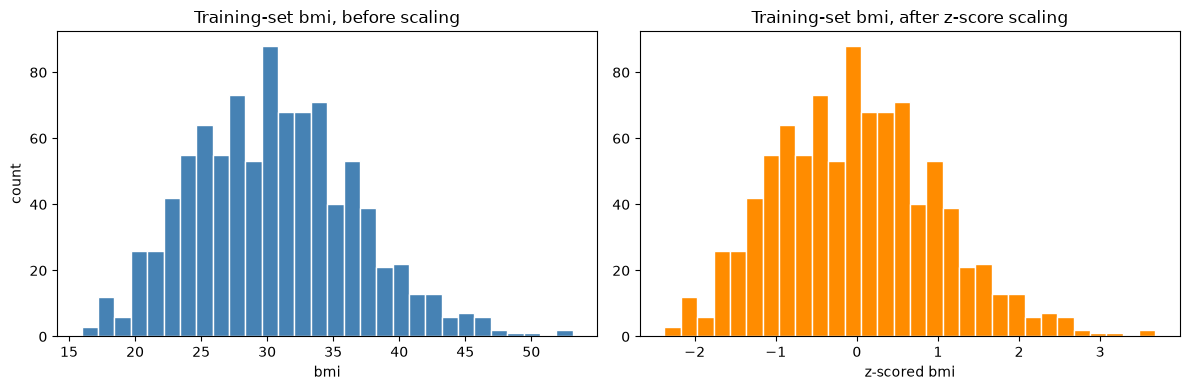

In [15]:
# Distribution of training-set bmi before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df["bmi"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Training-set bmi, before scaling")
axes[0].set_xlabel("bmi"); axes[0].set_ylabel("count")
axes[1].hist(train_scaled["bmi"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Training-set bmi, after z-score scaling")
axes[1].set_xlabel("z-scored bmi")
plt.tight_layout()
plt.show()

### Q6: Why the scaler must not be fit on the full dataset (3-4 sentences)

The test set exists to simulate **future unseen data**, data whose statistics we could not possibly have known at training time. If the scaler's mean and standard deviation are computed from the full dataset before splitting, then the test rows have already influenced the preprocessing that every training example passes through, so information flows from test to train before evaluation ever begins. This is a form of **data leakage**: the model is evaluated on data that helped define its own inputs, which makes the measured test performance **optimistically biased**, and this optimism silently vanishes in real deployment where genuinely new data arrives. The same logic is why hyperparameters are tuned on the *validation* set and the test set is touched exactly once, at the very end.

Note the shape of the histogram is unchanged by scaling. Z-scoring is a linear transformation (shift by mu, divide by sigma), so only the axis is relabeled, with 0 now at the training mean.